In [135]:
# Standard Data Package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Datetime Package
from datetime import datetime

# Serialization Package
import joblib

In [136]:
data = joblib.load("../data/processed/cleaned_data.pkl")

In [137]:
# Data Preview
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


- We can create monthly cohort by using each customer first ever transaction from the `InvoiceDate`.
- Before that, we can separate the month and year information from `InvoiceDate` to make it easier to create cohort columns and group each transaction by months.


In [237]:
# Extracting Month from InvoiceDate
data['Month'] = data['InvoiceDate'].apply(lambda x: datetime(x.year, x.month, 1))

# Validation
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price,Month,CohortMonth,CohortIndex
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12-01,2009-12-01,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12-01,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12-01,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12-01,2009-12-01,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12-01,2009-12-01,0


- Now let's find each customer first transaction to group them by cohorts.

In [193]:
# Create and Extract each customer Cohortmonth
data['CohortMonth'] = data.groupby(by='Customer ID')['Month'].transform('min')

# Validation
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price,Month,CohortMonth,CohortIndex
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12-01,2009-12-01,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12-01,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12-01,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12-01,2009-12-01,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12-01,2009-12-01,0


Now that we have this, we can create an index to calculate how many months have passed since the customer's first transaction for each transaction made by the customer .

In [238]:
# Creating Cohort Index for each transaction
def calculate_cohortindex(data_cohort):
    "Calculate month difference from first transaction to the current transaction"

    cohort_month = data_cohort['CohortMonth'].dt.month
    cohort_year = data_cohort['CohortMonth'].dt.year

    tn_month = data_cohort['Month'].dt.month
    tn_year = data_cohort['Month'].dt.year

    monthdiff = tn_month-cohort_month
    yeardiff = tn_year - cohort_year

    index = yeardiff*12 + monthdiff 

    return index

In [239]:
data['CohortIndex']= calculate_cohortindex(data)

# Validation
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total_Price,Month,CohortMonth,CohortIndex
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12-01,2009-12-01,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12-01,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12-01,2009-12-01,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12-01,2009-12-01,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12-01,2009-12-01,0


### Number of Customers Retained

Now let's see how many customers make transactions each month from each cohort.

In [240]:
cohort_data = data.groupby(['CohortMonth','CohortIndex'])['Customer ID'].agg("nunique").reset_index(name = "NumCustomer")

# Validation
cohort_data.head(12)

,CohortMonth,CohortIndex,NumCustomer
0,2009-12-01,0,955
1,2009-12-01,1,337
2,2009-12-01,2,319
3,2009-12-01,3,406
4,2009-12-01,4,363
5,2009-12-01,5,343
6,2009-12-01,6,360
7,2009-12-01,7,327
8,2009-12-01,8,321
9,2009-12-01,9,346


We can use pivot table and apply heatmap to visualize the data better.

In [243]:
cohort_pivot = cohort_data.pivot_table(
    index="CohortMonth",
    columns="CohortIndex",
    values="NumCustomer"
)
cohort_pivot.index = cohort_pivot.index.strftime('%b-%Y')

# Validation
cohort_pivot

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
Dec-2009,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,403.0,473.0,237.0
Jan-2010,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,116.0,38.0,NaN
Feb-2010,376.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,27.0,NaN,NaN
Mar-2010,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,35.0,NaN,NaN,NaN
Apr-2010,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,20.0,NaN,NaN,NaN,NaN
May-2010,254.0,40.0,43.0,44.0,45.0,65.0,54.0,20.0,NaN,NaN,NaN,NaN,NaN
Jun-2010,270.0,47.0,51.0,55.0,62.0,77.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN
Jul-2010,186.0,29.0,34.0,55.0,54.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Aug-2010,162.0,33.0,48.0,52.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


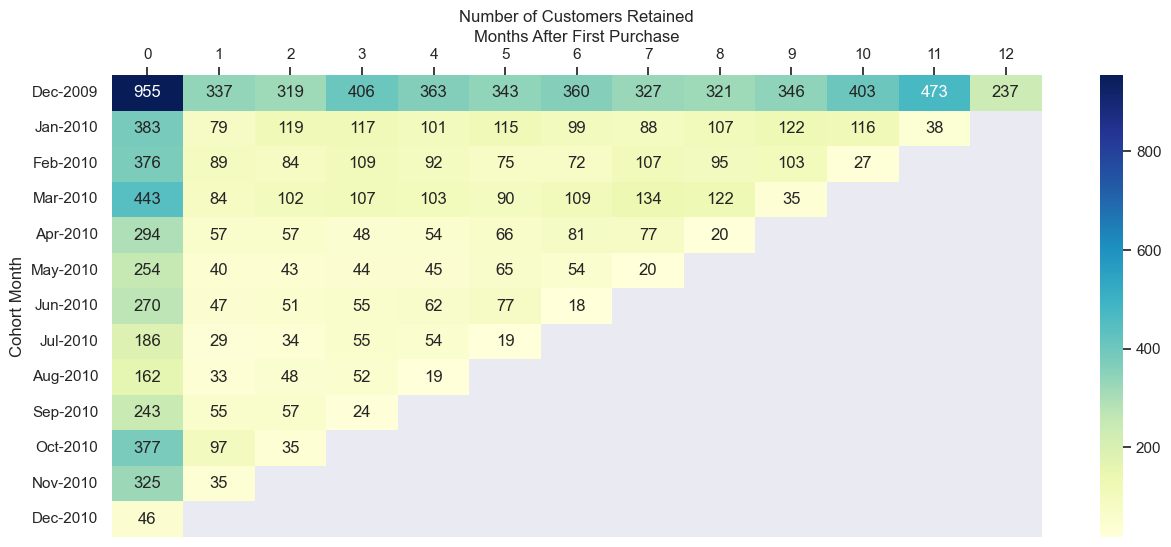

In [ ]:
plt.figure(figsize=(15,6))
plt.title("Number of Customers Retained")
sns.heatmap(cohort_pivot, annot=True, fmt = ".0f", cmap="YlGnBu")
plt.ylabel('Cohort Month')
plt.xlabel('Months After First Purchase')
plt.grid(False)

# Move the x axis to the top
ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.show()

- We can see that Dec-2009 acquired the most number of customers.
- From April to September, there is a big drop in the number of customers acquired.
- Since the data only contains transaction from 1st December 2009 to 9th December 2010, the low retained and acquired customer was due to incomplete data.

### Customer Retention Rates

- Now we can normalize the data so we can see the retention rates clearly regardless of the number of customers in each cohort.

In [245]:
retention = cohort_pivot.divide(cohort_pivot[0], axis=0)
retention

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
Dec-2009,1.0,0.352880,0.334031,0.425131,0.380105,0.359162,0.376963,0.342408,0.336126,0.362304,0.421990,0.495288,0.248168
Jan-2010,1.0,0.206266,0.310705,0.305483,0.263708,0.300261,0.258486,0.229765,0.279373,0.318538,0.302872,0.099217,NaN
Feb-2010,1.0,0.236702,0.223404,0.289894,0.244681,0.199468,0.191489,0.284574,0.252660,0.273936,0.071809,NaN,NaN
Mar-2010,1.0,0.189616,0.230248,0.241535,0.232506,0.203160,0.246050,0.302483,0.275395,0.079007,NaN,NaN,NaN
Apr-2010,1.0,0.193878,0.193878,0.163265,0.183673,0.224490,0.275510,0.261905,0.068027,NaN,NaN,NaN,NaN
May-2010,1.0,0.157480,0.169291,0.173228,0.177165,0.255906,0.212598,0.078740,NaN,NaN,NaN,NaN,NaN
Jun-2010,1.0,0.174074,0.188889,0.203704,0.229630,0.285185,0.066667,NaN,NaN,NaN,NaN,NaN,NaN
Jul-2010,1.0,0.155914,0.182796,0.295699,0.290323,0.102151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Aug-2010,1.0,0.203704,0.296296,0.320988,0.117284,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


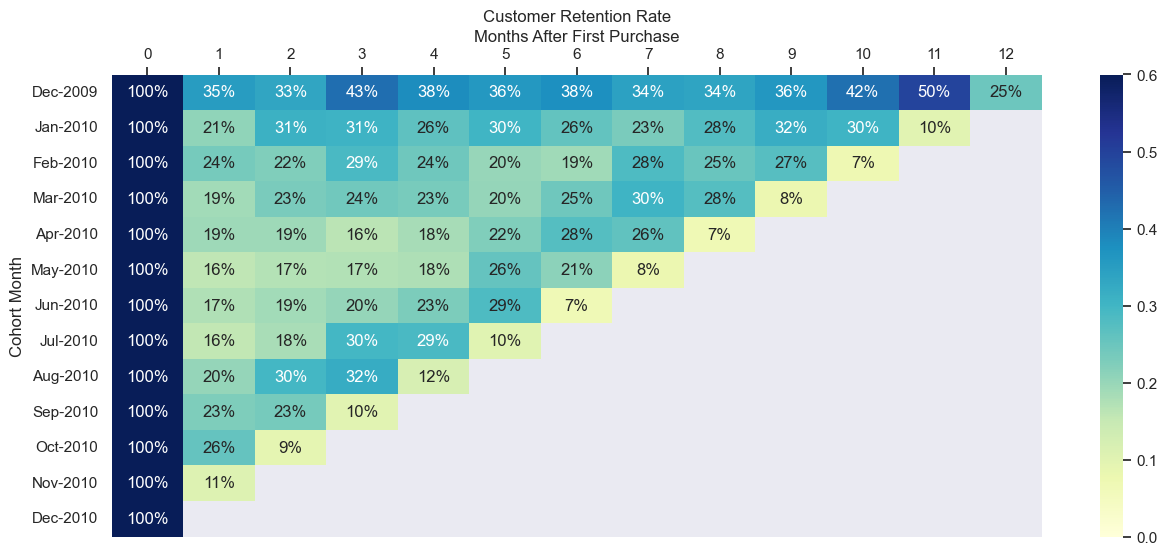

In [ ]:
plt.figure(figsize=(15,6))
plt.title("Customer Retention Rate")
sns.heatmap(retention, annot=True, fmt=".0%", cmap="YlGnBu", vmin = 0.0 , vmax = 0.6)
plt.ylabel('Cohort Month')
plt.xlabel('Months After First Purchase')
plt.grid(False)

# Move the x axis to the top
ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.show()


- Let's exclude the Dec-2010 transaction data.

In [271]:
# Create an df full of trues
mask = pd.DataFrame(True, index=retention.index, columns=retention.columns)

n = len(retention)
# Mark the anti-diagonal as false
for i in range(n):
    mask.iloc[i, n - 1 - i] = False

mask

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
Dec-2009,True,True,True,True,True,True,True,True,True,True,True,True,False
Jan-2010,True,True,True,True,True,True,True,True,True,True,True,False,True
Feb-2010,True,True,True,True,True,True,True,True,True,True,False,True,True
Mar-2010,True,True,True,True,True,True,True,True,True,False,True,True,True
Apr-2010,True,True,True,True,True,True,True,True,False,True,True,True,True
May-2010,True,True,True,True,True,True,True,False,True,True,True,True,True
Jun-2010,True,True,True,True,True,True,False,True,True,True,True,True,True
Jul-2010,True,True,True,True,True,False,True,True,True,True,True,True,True
Aug-2010,True,True,True,True,False,True,True,True,True,True,True,True,True


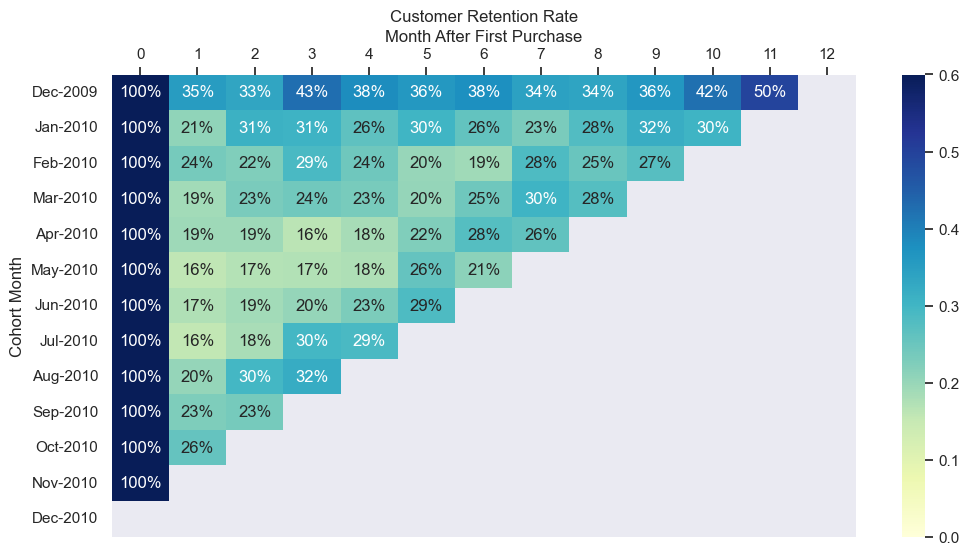

In [ ]:
retention_masked = retention[mask].copy()

plt.figure(figsize=(12,6))
plt.title("Customer Retention Rate")
sns.heatmap(retention_masked, annot=True, fmt=".0%", cmap="YlGnBu", vmin = 0.0 , vmax = 0.6)
plt.ylabel('Cohort Month')
plt.xlabel('Month After First Purchase')
plt.grid(False)

# Move the x axis to the top
ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.show()

- We can see that cohort Dec-2009 have a significantly higher retention rate. This may indicate that the marketing initiatives during that month were very successful and should potentially repeated.
- It appears that the retention rate for March to July cohort tends to decrease more significantly after the first month.
- Generally, retention rate decreases over time. However from our data we can see that there is an increase in the last 2-3 month on almost every cohort.
- I think we should visualize the retention by month to see the pattern more clearly.


In [273]:
cohort_data_month = data.groupby(['CohortMonth','Month'])['Customer ID'].agg("nunique").reset_index(name = "NumCustomer")

cohort_data_month

,CohortMonth,Month,NumCustomer
0,2009-12-01,2009-12-01,955
1,2009-12-01,2010-01-01,337
2,2009-12-01,2010-02-01,319
3,2009-12-01,2010-03-01,406
4,2009-12-01,2010-04-01,363
...,...,...,...
86,2010-10-01,2010-11-01,97
87,2010-10-01,2010-12-01,35
88,2010-11-01,2010-11-01,325
89,2010-11-01,2010-12-01,35


In [274]:
monthly_table = pd.pivot_table(cohort_data_month, values='NumCustomer', index='CohortMonth', columns='Month')
monthly_table.index = monthly_table.index.strftime('%b-%Y')

monthly_table

Month,2009-12-01,2010-01-01,2010-02-01,2010-03-01,2010-04-01,2010-05-01,2010-06-01,2010-07-01,2010-08-01,2010-09-01,2010-10-01,2010-11-01,2010-12-01
CohortMonth,,,,,,,,,,,,,
Dec-2009,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,403.0,473.0,237.0
Jan-2010,NaN,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,116.0,38.0
Feb-2010,NaN,NaN,376.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,27.0
Mar-2010,NaN,NaN,NaN,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,35.0
Apr-2010,NaN,NaN,NaN,NaN,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,20.0
May-2010,NaN,NaN,NaN,NaN,NaN,254.0,40.0,43.0,44.0,45.0,65.0,54.0,20.0
Jun-2010,NaN,NaN,NaN,NaN,NaN,NaN,270.0,47.0,51.0,55.0,62.0,77.0,18.0
Jul-2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,186.0,29.0,34.0,55.0,54.0,19.0
Aug-2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162.0,33.0,48.0,52.0,19.0


In [275]:
retention_by_month = monthly_table.divide(cohort_pivot[0], axis=0)
retention_by_month.columns = retention_by_month.columns.strftime('%b-%Y')

# Drop Dec-2010 due to incomplete data
retention_by_month.drop(columns='Dec-2010', inplace=True)
retention_by_month.drop(index='Dec-2010', inplace=True)

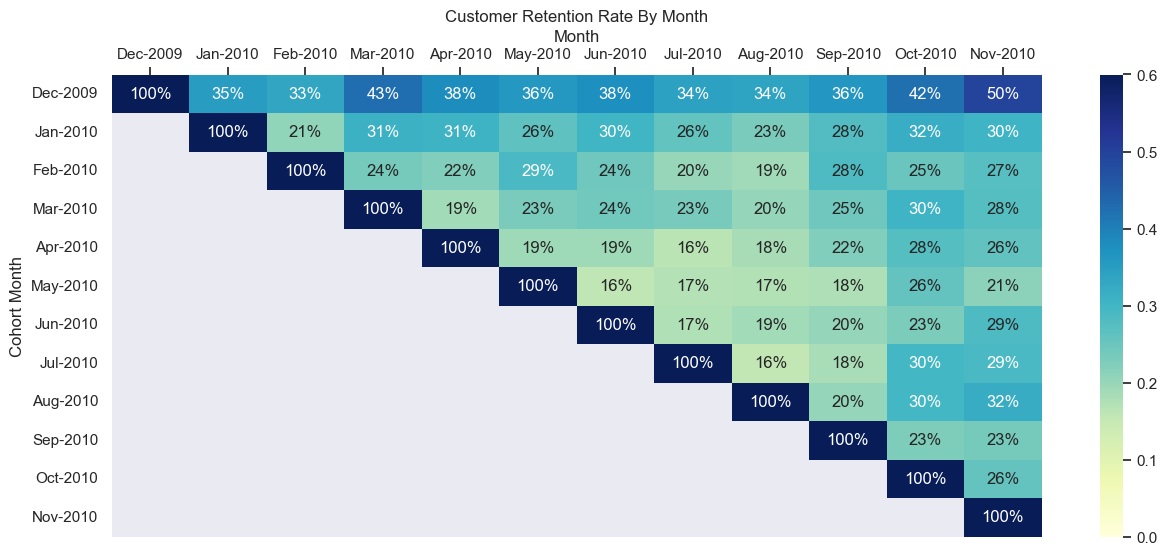

In [ ]:
plt.figure(figsize=(15,6))
plt.title("Customer Retention Rate By Month")
sns.heatmap(retention_by_month, annot=True, fmt=".0%", cmap="YlGnBu", vmin = 0.0 , vmax = 0.6)
plt.ylabel('Cohort Month')
plt.xlabel('Month')
plt.grid(False)

# Move the x axis to the top
ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.show()

- We can see that there is an increase at the end of the period and a decrease in the middle of the period, Let's make a line plot from this table to see if it helps reveal the pattern.
- Let's exclude each cohorts first month so as not to distort the line plot.

In [277]:
# mask the diagonal
mask_diag = pd.DataFrame(True, index=retention_by_month.index, columns=retention_by_month.columns ) 

for i in range(len(retention_by_month)):
    mask_diag.iloc[i,i] = False

mask_diag

Month,Dec-2009,Jan-2010,Feb-2010,Mar-2010,Apr-2010,May-2010,Jun-2010,Jul-2010,Aug-2010,Sep-2010,Oct-2010,Nov-2010
CohortMonth,,,,,,,,,,,,
Dec-2009,False,True,True,True,True,True,True,True,True,True,True,True
Jan-2010,True,False,True,True,True,True,True,True,True,True,True,True
Feb-2010,True,True,False,True,True,True,True,True,True,True,True,True
Mar-2010,True,True,True,False,True,True,True,True,True,True,True,True
Apr-2010,True,True,True,True,False,True,True,True,True,True,True,True
May-2010,True,True,True,True,True,False,True,True,True,True,True,True
Jun-2010,True,True,True,True,True,True,False,True,True,True,True,True
Jul-2010,True,True,True,True,True,True,True,False,True,True,True,True
Aug-2010,True,True,True,True,True,True,True,True,False,True,True,True


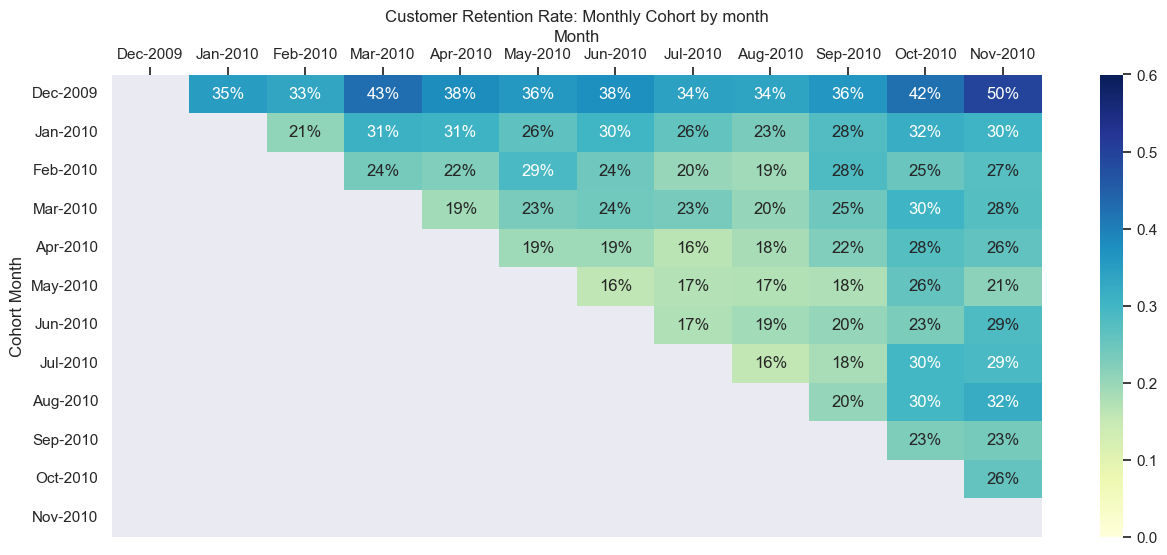

In [ ]:
plt.figure(figsize=(15,6))
plt.title("Customer Retention Rate: Monthly Cohort by month")
sns.heatmap(retention_by_month[mask_diag], annot=True, fmt=".0%", cmap="YlGnBu", vmin = 0.0 , vmax = 0.6)
plt.ylabel('Cohort Month')
plt.xlabel('Month')
plt.grid(False)

# Move the x axis to the top
ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.show()

 Now we can create the line plot.

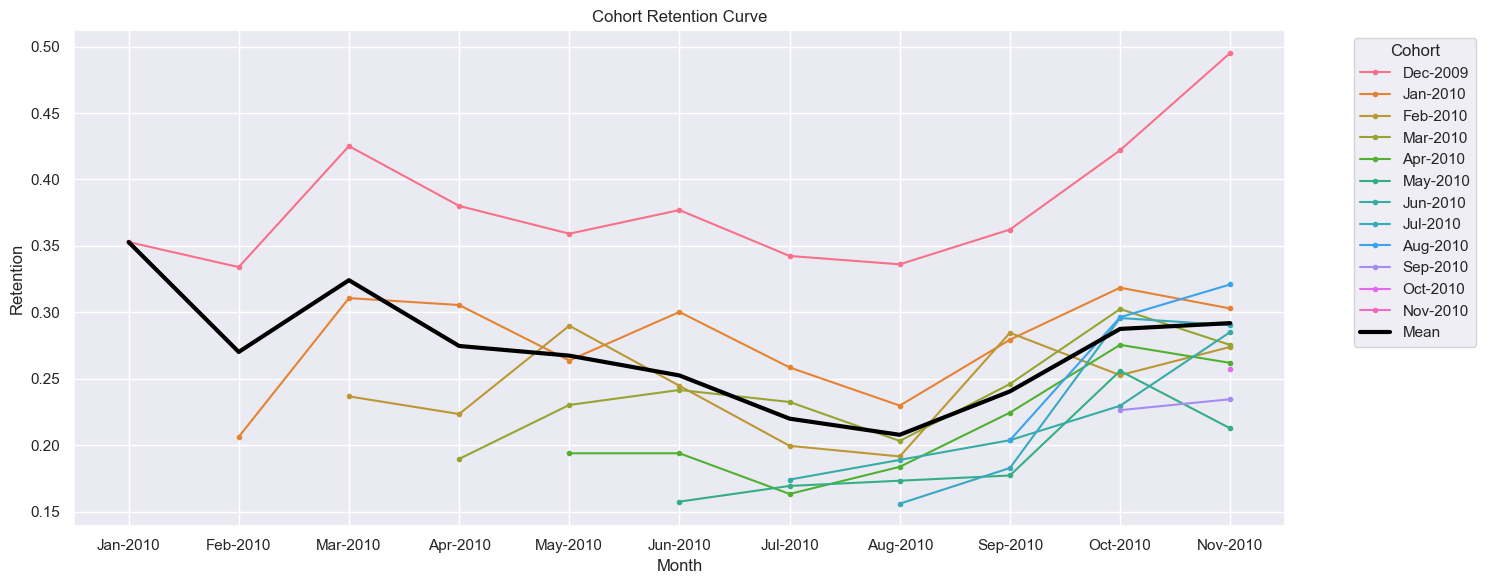

In [279]:
plt.figure(figsize=(15,6))

palette = sns.color_palette("husl", len(retention_by_month[mask_diag].index))

for i, cohort in enumerate(retention_by_month[mask_diag].index):
    plt.plot(
        retention_by_month[mask_diag].columns,
        retention_by_month[mask_diag].loc[cohort],
        marker=".",
        color=palette[i],
        label=str(cohort)
    )

mean = retention_by_month[mask_diag].mean()
plt.plot(mean, color = 'black', linewidth=3, label = 'Mean')

plt.title("Cohort Retention Curve")
plt.xlabel("Month")
plt.ylabel("Retention")
plt.legend(title="Cohort", bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


- Notice that there is a simultaneous increase in retention rate through September, October, and November 2010.
- We can also see declining retention rate on June to August.
- This simultaneous increase or decrease may be due to  marketing strategies that are implemented during those months or seasonal effects that encourage many customers to return or churn.
- The marketing strategy must be adjusted from June to August so that the period can have better retention.


### Average Cumulative Sales Per Customer by Cohort

Now let's calculate the average cumulative sales per Cohort to see which cohort deliver more value over time than others.

In [281]:
# Calculate Sum of sales of each month by each cohort
cohort_sales = data.groupby(['CohortMonth','CohortIndex'])['Total_Price'].sum()

#Validation
cohort_sales.head()

CohortMonth  CohortIndex
2009-12-01   0              683504.010
             1              394723.981
             2              295931.572
             3              378663.120
             4              305901.290
Name: Total_Price, dtype: float64

Now let's pivot the data so we can see it more clearly.

In [283]:
# Pivot table
pivot = cohort_sales.unstack('CohortIndex')
pivot.index = pivot.index.strftime('%b-%Y')
pivot

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
Dec-2009,683504.010,394723.981,295931.572,378663.120,305901.29,305066.66,301963.28,312812.830,331787.09,391539.48,460559.66,571512.942,184672.14
Jan-2010,161078.691,38985.350,50955.470,57400.211,58528.89,60795.09,51990.10,48004.070,60459.54,74544.04,76602.00,21991.750,NaN
Feb-2010,169642.034,33174.620,54677.760,53236.910,43906.71,39565.70,40078.67,51089.571,52810.88,54630.03,12022.37,NaN,NaN
Mar-2010,234185.261,49737.450,51722.750,64507.630,50115.97,55850.23,65378.39,81126.030,76267.27,13995.03,NaN,NaN,NaN
Apr-2010,124265.291,18871.040,20579.410,30099.750,22224.76,30769.05,35105.30,32670.450,4979.15,NaN,NaN,NaN,NaN
May-2010,110407.130,13574.650,14065.400,12685.680,16861.31,31174.36,23140.53,4575.610,NaN,NaN,NaN,NaN,NaN
Jun-2010,131044.360,16038.770,22546.500,25780.810,34934.40,48306.23,9299.55,NaN,NaN,NaN,NaN,NaN,NaN
Jul-2010,75047.650,8384.300,13690.610,24927.850,28658.50,6791.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Aug-2010,60663.300,13797.990,23029.070,23403.830,8154.47,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Now add up the sales each month to make it cumulative.

In [284]:
cumulative = pivot.cumsum(axis=1)

#validation
cumulative

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
Dec-2009,683504.010,1078227.991,1374159.563,1752822.683,2058723.973,2363790.633,2665753.913,2978566.743,3310353.833,3701893.313,4162452.973,4733965.915,4918638.055
Jan-2010,161078.691,200064.041,251019.511,308419.722,366948.612,427743.702,479733.802,527737.872,588197.412,662741.452,739343.452,761335.202,NaN
Feb-2010,169642.034,202816.654,257494.414,310731.324,354638.034,394203.734,434282.404,485371.975,538182.855,592812.885,604835.255,NaN,NaN
Mar-2010,234185.261,283922.711,335645.461,400153.091,450269.061,506119.291,571497.681,652623.711,728890.981,742886.011,NaN,NaN,NaN
Apr-2010,124265.291,143136.331,163715.741,193815.491,216040.251,246809.301,281914.601,314585.051,319564.201,NaN,NaN,NaN,NaN
May-2010,110407.130,123981.780,138047.180,150732.860,167594.170,198768.530,221909.060,226484.670,NaN,NaN,NaN,NaN,NaN
Jun-2010,131044.360,147083.130,169629.630,195410.440,230344.840,278651.070,287950.620,NaN,NaN,NaN,NaN,NaN,NaN
Jul-2010,75047.650,83431.950,97122.560,122050.410,150708.910,157500.530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Aug-2010,60663.300,74461.290,97490.360,120894.190,129048.660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Then, devide each row to it's corresponding cohort size.

In [232]:
avg_cum_sales = cumulative.divide(cohort_pivot[0], axis=0)

avg_cum_sales

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
Dec-2009,715.711005,1129.034546,1438.910537,1835.416422,2155.731909,2475.173438,2791.365354,3118.918055,3466.339092,3876.328076,4358.589501,4957.032372,5150.40634
Jan-2010,420.570995,522.360420,655.403423,805.273426,958.090371,1116.824287,1252.568674,1377.905671,1535.763478,1730.395436,1930.400658,1987.820371,NaN
Feb-2010,451.175622,539.405995,684.825569,826.413096,943.186261,1048.414186,1155.006394,1290.882912,1431.337380,1576.630013,1608.604402,NaN,NaN
Mar-2010,528.634901,640.909054,757.664698,903.280115,1016.408716,1142.481470,1290.062485,1473.191221,1645.352102,1676.943591,NaN,NaN,NaN
Apr-2010,422.671058,486.858269,556.856262,659.236364,734.830786,839.487418,958.893201,1070.017180,1086.953065,NaN,NaN,NaN,NaN
May-2010,434.673740,488.117244,543.492835,593.436457,659.819567,782.553268,873.657717,891.671929,NaN,NaN,NaN,NaN,NaN
Jun-2010,485.349481,544.752333,628.257889,723.742370,853.129037,1032.041000,1066.483778,NaN,NaN,NaN,NaN,NaN,NaN
Jul-2010,403.481989,448.558871,522.164301,656.185000,810.262957,846.777043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Aug-2010,374.464815,459.637593,601.792346,746.260432,796.596667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Now we can visualize it on the heatmap.

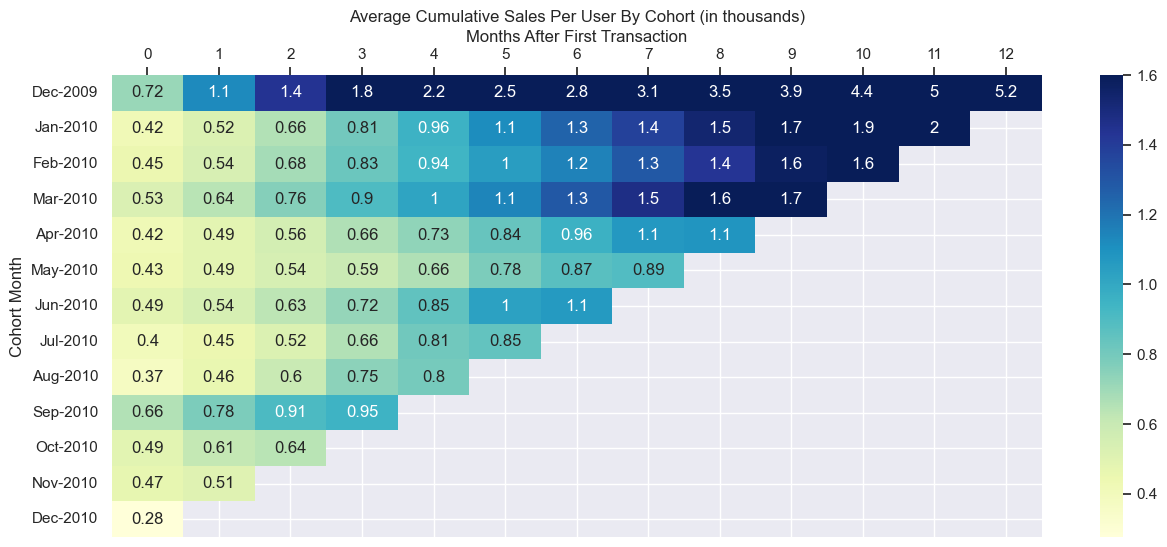

In [285]:
# in thousands
pivot_display = avg_cum_sales / 1000

plt.figure(figsize=(15,6))
plt.title("Average Cumulative Sales Per User By Cohort (in thousands)")
sns.heatmap(pivot_display, annot=True, cmap="YlGnBu", vmax=1.6)
plt.ylabel('Cohort Month')
plt.xlabel('Months After First Transaction')

# Move the x axis to the top
ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.show()

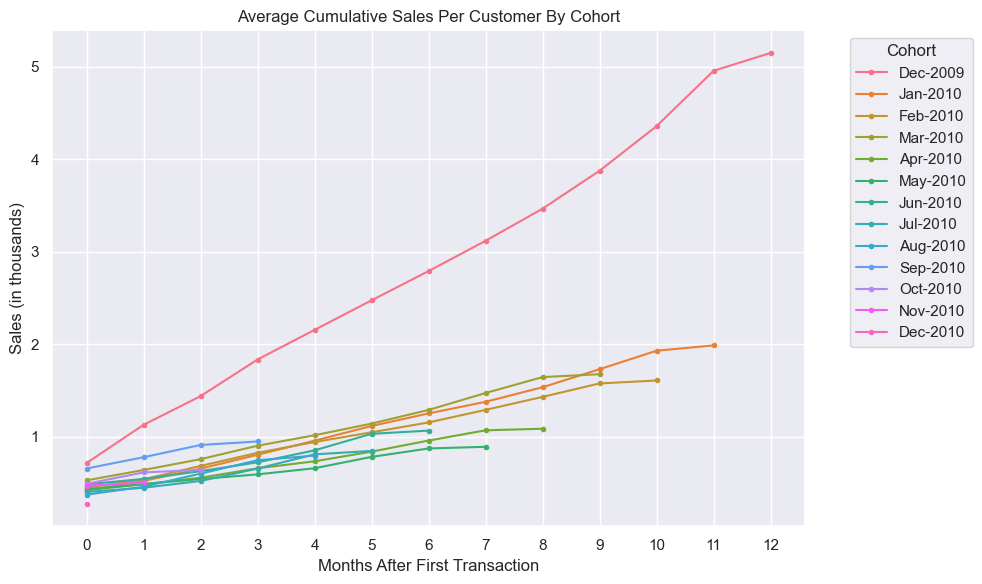

In [286]:
palette = sns.color_palette("husl", len(pivot_display.index))

plt.figure(figsize=(10,6))

for i, cohort in enumerate(pivot_display.index):
    plt.plot(
        pivot_display.columns,
        pivot_display.loc[cohort],
        marker=".",
        color=palette[i],
        label=str(cohort)
    )


plt.title("Average Cumulative Sales Per Customer By Cohort")
plt.xlabel("Months After First Transaction")
plt.xticks(pivot_display.columns)
plt.ylabel("Sales (in thousands)")
plt.legend(title="Cohort", bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

- On December 2009 and September 2010, We acquired noticably high value customer. The right marketing mix seems to have been applied to acquire high value customers. 
- The customers we acquired between April and August brought  less value to our company. 


### Summary Insights
- Dec-2009 acquired the most number of customers.
- From April to September, there is a big drop in the number of customers acquired.
- There is a simultaneous increase in retention rate through September, October, and November 2010.
- Retention rate for March to July cohort tends to decrease more significantly after the first month.
- We can also see declining retention rate on June to August.
- On Dec-2009 and Sep-2010, We acquired high value customer. 
- The customers we acquired between April and August brought less value compared to the others. 
-  There are no clear alignment between acquisiton volume, high customer value, and strong retention.

### Recommendation
- Replicate the acquisition strategies from Dec-2009 and Sep-2010, as these months brought many high-value customers.
- Investigate the April–September drop in customer acquisition and strengthen marketing efforts during this period.
- Apply the tactics that improved retention in Sep–Nov 2010 consistently across all cohorts.
- Address the retention decline in June–August with re-engagement campaigns and seasonal analysis.
- Increase the value of low-value cohorts (Apr–Aug) through upselling, cross-selling, and improved onboarding.
- Encourage early repeat purchases with welcome offers and personalized follow-ups, since many customers churn after the first month.